### <img src="../logoutn.jpg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 4

Farcy Facundo


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
@author: facu
"""

#-------------------------
# IMPORTACIÓN DE MÓDULOS Y CONFIGURACIONES PREVIAS
#------------------------
# Módulos externos

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13
#_=plt.grid(True, which="both")
mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq, pretty_print_SOS, plot_plantilla, tf2sos_analog
from pytc2.general import print_latex, a_equal_b_latex_s

import matplotlib.patches as patches
from matplotlib.path import Path


## ÍTEMS 1 - 2

In [3]:
from IPython.display import IFrame
IFrame("TS4.pdf", width=1000, height=1000)


## ÍTEM 3
Para el tercer ítem se pide la transferencia normalizada simulada en python y LTSpice.
Adelantando el final, sé que no se trata de un filtro butterworth, para lo pedido de ripple 1dB en w=1, ya que el butterworth indica un ripple de 3dB para dicha frecuencia. Sin embargo, sí se usó un butter de origen, escalado por el omega_w_2

#### En python

In [5]:
# Comienzo de la simulación
att_max = 1
oh_w_2 = 1/np.sqrt(np.sqrt(10 ** (att_max/10)-1))

g1=0;g2=1;g3=2;
cond=[1.,np.sqrt(2),1.]
c=0;
cap=[1.]

cond=np.array(cond);
cap=np.array(cap);

# Cargamos la funcion transferencia como vectores de sus coeficientes.
num_butt = np.array([((cond[g3]/cap[c])**2)*cond[g1]/cond[g3]*(-1.)]);
den_butt = np.array([1., cond[g2]/cap[c],(cond[g3]/cap[c])**2]);
H1_butt = sig.TransferFunction( num_butt, den_butt )

cap=cap/oh_w_2

num = np.array([((cond[g3]/cap[c])**2)*cond[g1]/cond[g3]*(-1.)]);
den = np.array([ 1., cond[g2]/cap[c],(cond[g3]/cap[c])**2]);
H1 = sig.TransferFunction( num, den)
# mostramos la transferencia construida
print("Transferencia normalizada")
pretty_print_bicuad_omegayq(num,den)

Transferencia normalizada


<IPython.core.display.Math object>

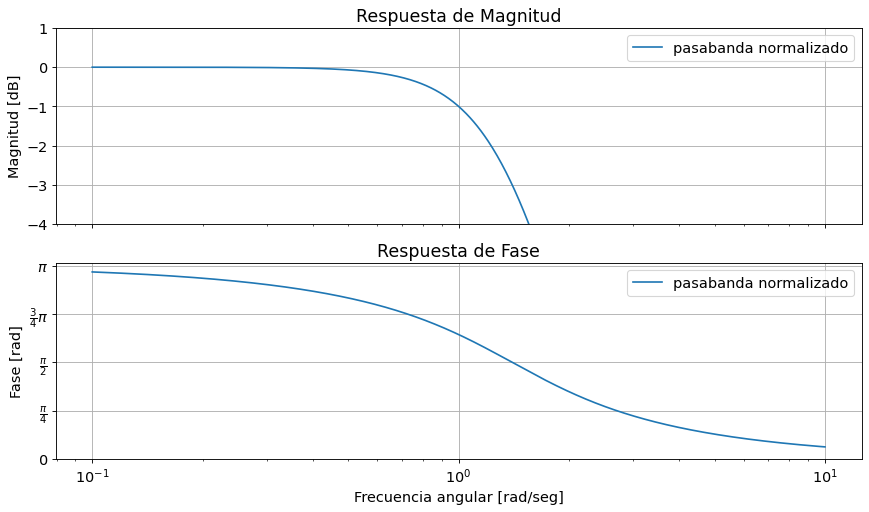

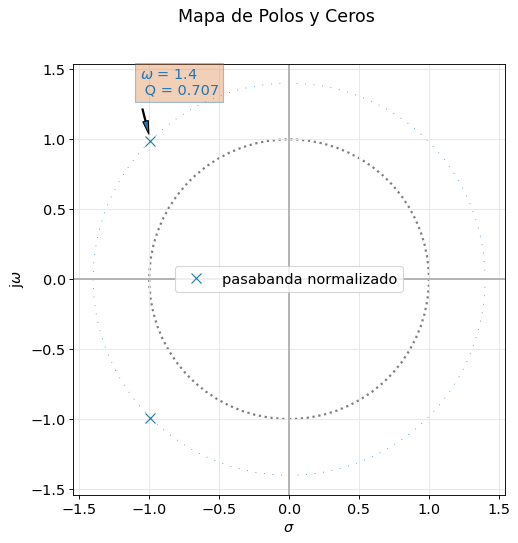

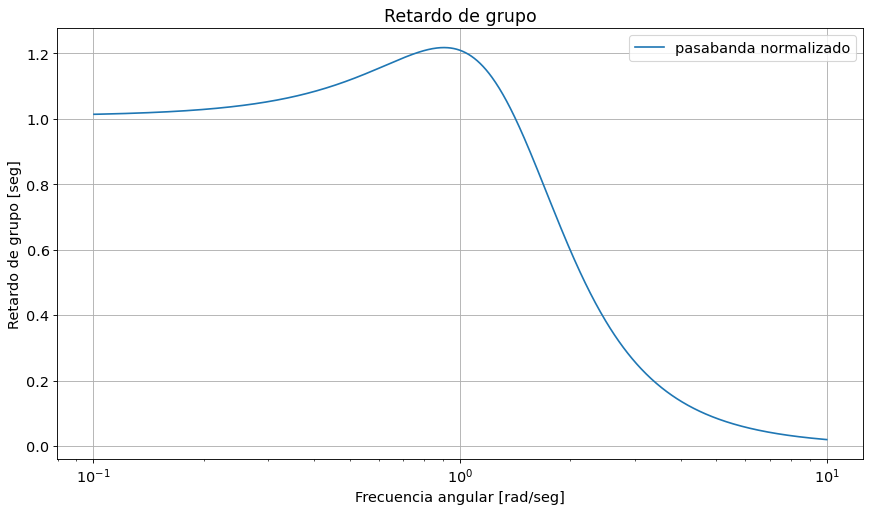

In [32]:
a = analyze_sys([H1], sys_name='pasabanda normalizado')

a[0][1][0].set_ylim(top=1, bottom=-4);

Efectivamnte se puede ver que en w=1 hay menos de 3dB de att.

#### LTSpice
<img src="Spice1.png">
Efectivamente, en w=1 podemos medir que hay una att de 1dB.
Además, en ambos casos se puede notar que la respuesta es de maxima planicidad

### BONUS 1

EL bonus 1 plantea realizar el filtro a partir de un ejemplo, donde se aplica la transformación con el ohmega butter, que es exactamente el método de resolución empleado en el ítem 1, con la diferencia de que yo realicé el método de partes 